In [1]:
import akshare as ak
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta


In [9]:
#整合买卖信号
def  allsingal(df):
    df['buy_signal']=np.where((df['buy_signal']==1) & (df['buy_signal'].shift(1) ==1) ,0,df['buy_signal'])#只保留第一个信号
    df['sell_signal']=np.where((df['sell_signal']==-1) & (df['sell_signal'].shift(1) ==-1) ,0,df['sell_signal'])
    df['signal']=df['buy_signal']+df['sell_signal']
    df.drop([ 'buy_signal','sell_signal'],axis=1) 
    df=df[df['signal'] !=0 ] 
    return df            #返回整合买卖信号的df


In [11]:
#按照每笔交易计算收益率(而非每日净值)
def cal_r(df):
    df=df[df['signal'] !=0 ]             #时间序列变成了仅交易日序列
    df['r']=df['收盘'].pct_change()  #收益率:当天交易收盘价-上一次交易收盘价/当天交易收盘价
    df=df[df['signal'] ==-1 ]          #时间序列变成了仅卖出日序列
    df['cumr']=(1+df['r']).cumprod() - 1   #按照每笔交易计算累计收益率
    return df


In [13]:
#双均线策略
def ma_strategy(df, short_window, long_window):
    #计算长短均线
    df['short_ma']=df['涨跌幅'].rolling(short_window).mean()
    df['long_ma']=df['涨跌幅'].rolling(long_window).mean()
    #生成买卖信号
    df['buy_signal']=np.where((df['short_ma']>df['long_ma']),1,0)
    df['sell_signal']=np.where((df['short_ma']<df['long_ma']),-1,0)
    #整合信号
    df=allsingal(df) 
    
    return df[['收盘','short_ma','long_ma','signal']]  


In [91]:
#使用策略并计算收益率
end_date=datetime.now().strftime("%Y%m%d")
start_date = (datetime.now()- timedelta(days=365)).strftime("%Y%m%d")
df=ak.stock_zh_a_hist("002594", start_date=start_date , end_date=end_date,period="daily", adjust="")             #获取数据开始时间比想测试时间更早1个long_window
df.set_index('日期', inplace=True)
df_ma=ma_strategy(df,short_window=10, long_window=20)
df_ma_r=cal_r(df_ma)
print("开仓次数:",len(df_ma_r.dropna()))
print(df_ma)
print(df_ma_r)
print("夏普比:",df_ma_r["r"].mean() / df_ma_r["r"].std() *np.sqrt(242) ,"累计收益率:",df_ma_r["cumr"].iloc[-1])

开仓次数: 16
                收盘  short_ma  long_ma  signal
日期                                           
2024-05-30  227.86     0.469   0.1715       1
2024-06-19  254.00     0.663   0.7780      -1
2024-07-11  253.06     0.149   0.0075       1
2024-07-24  249.99    -0.079  -0.0395      -1
2024-08-15  231.49    -0.519  -0.5890       1
2024-09-04  250.32     0.409   0.4655      -1
2024-09-06  251.60     0.530   0.4320       1
2024-09-10  249.65     0.392   0.4560      -1
2024-09-11  258.10     0.894   0.6715       1
2024-09-13  254.99     0.237   0.4250      -1
2024-09-18  258.43     0.706   0.4860       1
2024-09-19  255.36     0.339   0.4040      -1
2024-09-25  262.80     0.518   0.4905       1
2024-10-18  300.30     0.670   0.8275      -1
2024-11-05  307.50     0.119  -0.2675       1
2024-11-06  300.36    -0.249  -0.0520      -1
2024-11-07  301.78    -0.034  -0.1955       1
2024-11-08  297.90    -0.310  -0.0095      -1
2024-11-15  290.00     0.012  -0.1550       1
2024-11-18  288.68    -0.

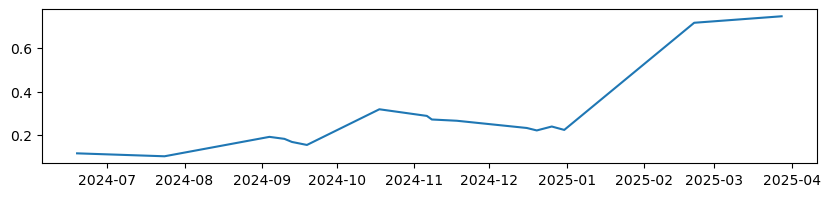

In [93]:
plt.rcParams["figure.figsize"] = [10, 2] 
plt.plot(df_ma_r.index,df_ma_r['cumr']) 

(array([6., 4., 1., 1., 0., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([-0.02638102, -0.01202949,  0.00232204,  0.01667357,  0.03102509,
         0.04537662,  0.05972815,  0.07407968,  0.08843121,  0.10278274,
         0.11713426,  0.13148579,  0.14583732,  0.16018885,  0.17454038,
         0.18889191,  0.20324344,  0.21759496,  0.23194649,  0.24629802,
         0.26064955,  0.27500108,  0.28935261,  0.30370413,  0.31805566,
         0.33240719,  0.34675872,  0.36111025,  0.37546178,  0.38981331,
         0.40416483]),
 <BarContainer object of 30 artists>)

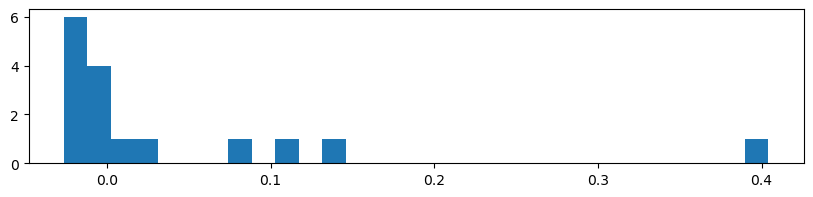

In [95]:
returns=df_ma_r['r']     #获取每笔交易收益率并观察分布情况
plt.hist(returns,bins=30) 

In [97]:
from scipy.stats import ttest_1samp
t,p=ttest_1samp(returns,0,nan_policy="omit") #检验收益是否显著大于0
p_value=p/2                              #单边检测p/2
print("使用显著水平0.05，当t>0，p_value<0.05时说明收益显著大于0, t和p_value值为:")
print(t , p_value, "是否显著大于0:",p_value<0.05)


使用显著水平0.05，当t>0，p_value<0.05时说明收益显著大于0, t和p_value值为:
1.4648736299400407 0.08179991629188381 是否显著大于0: False


In [79]:
#测试不使用策略股票被动收益
def pass_r(df):
    returns = df['涨跌幅'] / 100            
    avg_return=returns.mean()           #日平均收益                  
    year_return=avg_return*242                #不考虑复利的年化收益率
    total_return = (1 + returns).prod() - 1  # 每日累计收益
    cagr = (1 + total_return) ** (242 / len(df)) - 1  # 累计收益折算年化
    b_price,s_price = df["收盘"].iloc[0], df["收盘"].iloc[-1]
    buy_hold_return = (s_price - b_price) / b_price       #这段时间买入股票持有不动的收益率
    sharpe=returns.mean() / returns.std() * np.sqrt(242)
    print("不考虑复利的年化收益率:",year_return,"这段时间买入股票持有不动的收益率:",buy_hold_return,"年夏普比:",sharpe)
    return  year_return, buy_hold_return,sharpe


In [81]:
pass_r(df)


不考虑复利的年化收益率: 0.5377777777777778 这段时间买入股票持有不动的收益率: 0.619908466819222 年夏普比: 1.4276919741569447


(0.5377777777777778, 0.619908466819222, 1.4276919741569447)

(array([ 1.,  0.,  0.,  0.,  1.,  1.,  0.,  1.,  4.,  3.,  3., 12., 20.,
        40., 36., 37., 24., 19.,  8.,  8., 10.,  3.,  3.,  3.,  3.,  0.,
         0.,  2.,  0.,  1.]),
 array([-0.1       , -0.09333333, -0.08666667, -0.08      , -0.07333333,
        -0.06666667, -0.06      , -0.05333333, -0.04666667, -0.04      ,
        -0.03333333, -0.02666667, -0.02      , -0.01333333, -0.00666667,
         0.        ,  0.00666667,  0.01333333,  0.02      ,  0.02666667,
         0.03333333,  0.04      ,  0.04666667,  0.05333333,  0.06      ,
         0.06666667,  0.07333333,  0.08      ,  0.08666667,  0.09333333,
         0.1       ]),
 <BarContainer object of 30 artists>)

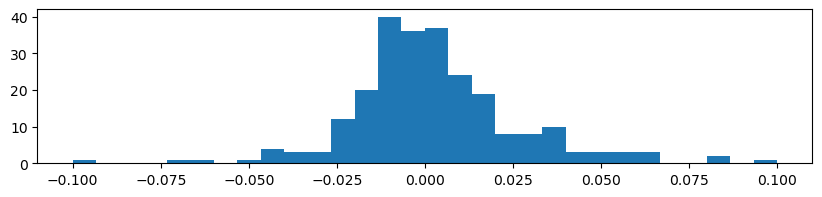

In [57]:
returns2=df['涨跌幅'] / 100   #获取每日收益率并查看其分布
plt.hist(returns2,bins=30) 

In [59]:
t2,p2=ttest_1samp(returns2,0,nan_policy="omit") #检验收益是否显著大于0  忽略空缺值
p_value2=p2/2                              #单边检测p/2
print("使用显著水平0.05，当t>0，p_value<0.05时说明收益显著大于0, t和p_value值为:")
print(t2 , p_value2, "是否显著大于0:",p_value2<0.05)


使用显著水平0.05，当t>0，p_value<0.05时说明收益显著大于0, t和p_value值为:
1.4628532989075678 0.0724025225673038 是否显著大于0: False


In [61]:
from scipy.stats import kurtosis, skew, jarque_bera

In [63]:
kurtosis(returns2, fisher=True)

2.8915954090850127

In [65]:
skew(returns2)

0.40193729183682503